In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

DATA_PATH = '../data/'

files = {
    'orders'                      : 'olist_orders_dataset.csv',
    'order_items'                 : 'olist_order_items_dataset.csv',
    'order_payments'              : 'olist_order_payments_dataset.csv',
    'order_reviews'               : 'olist_order_reviews_dataset.csv',
    'customers'                   : 'olist_customers_dataset.csv',
    'sellers'                     : 'olist_sellers_dataset.csv',
    'products'                    : 'olist_products_dataset.csv',
    'geolocation'                 : 'olist_geolocation_dataset.csv',
    'product_category_translation': 'product_category_name_translation.csv'
}

dfs = {}
for alias, filename in files.items():
    dfs[alias] = pd.read_csv(os.path.join(DATA_PATH, filename))

print('All 9 files reloaded ✓')

All 9 files reloaded ✓


In [2]:
date_columns = {
    'orders': [
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ],
    'order_reviews': [
        'review_creation_date',
        'review_answer_timestamp'
    ]
}

for table, cols in date_columns.items():
    for col in cols:
        dfs[table][col] = pd.to_datetime(dfs[table][col])
    print(f'  ✓  {table} — converted {len(cols)} date columns')

print('\nDate conversion done. New dtypes:')
print(dfs['orders'][date_columns['orders']].dtypes)

  ✓  orders — converted 5 date columns
  ✓  order_reviews — converted 2 date columns

Date conversion done. New dtypes:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [3]:
print('BEFORE cleaning — products missing values:')
print(dfs['products'].isnull().sum())

# Fill missing category name with 'unknown'
dfs['products']['product_category_name'] = dfs['products']['product_category_name'].fillna('unknown')

# Fill missing dimensions/weight with column median (safe assumption)
dimension_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in dimension_cols:
    median_val = dfs['products'][col].median()
    dfs['products'][col] = dfs['products'][col].fillna(median_val)

print('\nAFTER cleaning — products missing values:')
print(dfs['products'].isnull().sum())

BEFORE cleaning — products missing values:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

AFTER cleaning — products missing values:
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


In [4]:
print('BEFORE — order_reviews missing values:')
print(dfs['order_reviews'].isnull().sum())

# Comment title and message — fill with empty string (no comment left)
dfs['order_reviews']['review_comment_title'] = dfs['order_reviews']['review_comment_title'].fillna('no title')
dfs['order_reviews']['review_comment_message'] = dfs['order_reviews']['review_comment_message'].fillna('no comment')

print('\nAFTER — order_reviews missing values:')
print(dfs['order_reviews'].isnull().sum())

BEFORE — order_reviews missing values:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

AFTER — order_reviews missing values:
review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64


In [5]:
print(f'Geolocation rows BEFORE: {len(dfs["geolocation"]):,}')

dfs['geolocation'] = dfs['geolocation'].drop_duplicates(
    subset=['geolocation_zip_code_prefix', 'geolocation_city', 'geolocation_state']
)

print(f'Geolocation rows AFTER:  {len(dfs["geolocation"]):,}')
print(f'Duplicates removed: {1000163 - len(dfs["geolocation"]):,}')

Geolocation rows BEFORE: 1,000,163
Geolocation rows AFTER:  27,912
Duplicates removed: 972,251


In [6]:
orders = dfs['orders'].copy()

# 1. How many days did delivery actually take?
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

# 2. How many days early or late vs estimated?
orders['delivery_vs_estimate'] = (
    orders['order_estimated_delivery_date'] - orders['order_delivered_customer_date']
).dt.days
# Positive = delivered early, Negative = delivered late

# 3. Was the order late?
orders['is_late'] = orders['delivery_vs_estimate'] < 0

# 4. Year-month column for time series charts
orders['order_year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# 5. Day of week order was placed
orders['order_day_of_week'] = orders['order_purchase_timestamp'].dt.day_name()

# 6. Hour of day order was placed
orders['order_hour'] = orders['order_purchase_timestamp'].dt.hour

dfs['orders'] = orders

print('New columns added to orders:')
print(orders[['delivery_days', 'delivery_vs_estimate', 'is_late',
              'order_year_month', 'order_day_of_week', 'order_hour']].head(5))

New columns added to orders:
   delivery_days  delivery_vs_estimate  is_late order_year_month  \
0           8.00                  7.00    False          2017-10   
1          13.00                  5.00    False          2018-07   
2           9.00                 17.00    False          2018-08   
3          13.00                 12.00    False          2017-11   
4           2.00                  9.00    False          2018-02   

  order_day_of_week  order_hour  
0            Monday          10  
1           Tuesday          20  
2         Wednesday           8  
3          Saturday          19  
4           Tuesday          21  


In [7]:
delivered = dfs['orders'][dfs['orders']['order_status'] == 'delivered'].copy()

print('Delivery Days — Summary Stats:')
print(delivered['delivery_days'].describe())

print(f'\nLate orders: {delivered["is_late"].sum():,}  ({delivered["is_late"].mean()*100:.1f}%)')
print(f'On-time orders: {(~delivered["is_late"]).sum():,}  ({(~delivered["is_late"]).mean()*100:.1f}%)')

Delivery Days — Summary Stats:
count   96470.00
mean       12.09
std         9.55
min         0.00
25%         6.00
50%        10.00
75%        15.00
max       209.00
Name: delivery_days, dtype: float64

Late orders: 7,826  (8.1%)
On-time orders: 88,652  (91.9%)


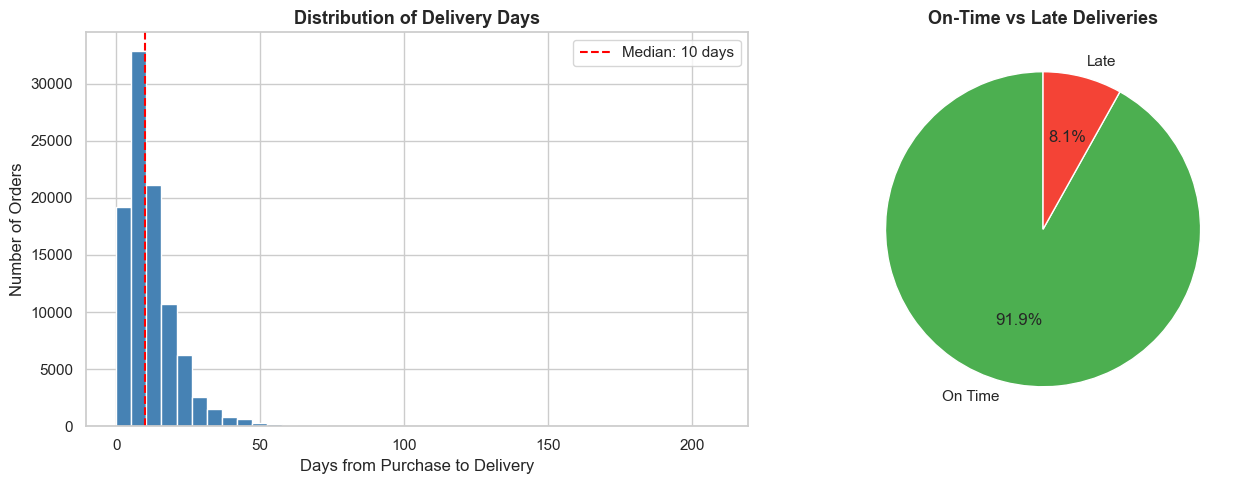

Saved to outputs/delivery_analysis.png


In [8]:
delivered = dfs['orders'][dfs['orders']['order_status'] == 'delivered'].copy()
delivered = delivered.dropna(subset=['delivery_days'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(delivered['delivery_days'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Delivery Days', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Days from Purchase to Delivery')
axes[0].set_ylabel('Number of Orders')
axes[0].axvline(delivered['delivery_days'].median(), color='red',
                linestyle='--', label=f'Median: {delivered["delivery_days"].median():.0f} days')
axes[0].legend()

# On-time vs Late pie
counts = delivered['is_late'].value_counts()
labels = ['On Time', 'Late']
axes[1].pie(counts, labels=labels, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[1].set_title('On-Time vs Late Deliveries', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/delivery_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/delivery_analysis.png')

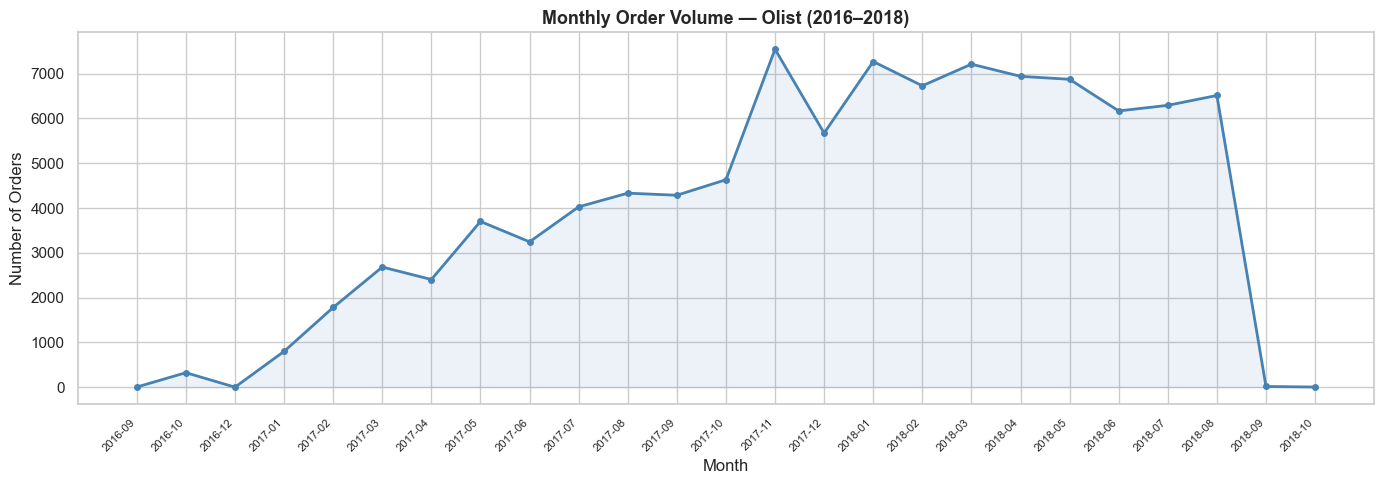

Saved to outputs/monthly_orders.png


In [9]:
monthly = (
    dfs['orders']
    .groupby('order_year_month')
    .size()
    .reset_index(name='order_count')
)

# Convert Period to string for plotting
monthly['order_year_month'] = monthly['order_year_month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly['order_year_month'], monthly['order_count'],
         marker='o', color='steelblue', linewidth=2, markersize=4)
plt.fill_between(range(len(monthly)), monthly['order_count'], alpha=0.1, color='steelblue')
plt.xticks(range(len(monthly)), monthly['order_year_month'], rotation=45, ha='right', fontsize=8)
plt.title('Monthly Order Volume — Olist (2016–2018)', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('../outputs/monthly_orders.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/monthly_orders.png')

In [10]:
output_tables = ['orders', 'order_items', 'order_payments',
                 'order_reviews', 'customers', 'sellers',
                 'products', 'geolocation', 'product_category_translation']

for name in output_tables:
    out_path = f'../data/cleaned_{name}.csv'
    dfs[name].to_csv(out_path, index=False)
    print(f'  ✓  saved cleaned_{name}.csv')

print('\nAll cleaned files saved to data/ folder!')

  ✓  saved cleaned_orders.csv
  ✓  saved cleaned_order_items.csv
  ✓  saved cleaned_order_payments.csv
  ✓  saved cleaned_order_reviews.csv
  ✓  saved cleaned_customers.csv
  ✓  saved cleaned_sellers.csv
  ✓  saved cleaned_products.csv
  ✓  saved cleaned_geolocation.csv
  ✓  saved cleaned_product_category_translation.csv

All cleaned files saved to data/ folder!
